# Dashcam Coverage Density vs. Socio-Economic Variables

This notebook explores the relationship between dashcam data density (from September 29, 2023) and socio-economic characteristics of NYC census tracts, using ACS 2023 data. The goal is to assess whether coverage systematically varies with demographic composition.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from pathlib import Path

import constants as c
import helpers as h
from logger import setup_logger

# use latex for all plots
plt.rcParams['text.usetex'] = True  
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

log = setup_logger('coverage-ses-corr')
log.setLevel('INFO')
log.info("Modules loaded.")

2026-05-31 12:31:20 - coverage-ses-corr - INFO - Modules loaded.


## 1. Load & Prepare Data

In [2]:
analysis_df = pd.read_csv(c.CURRENT_DF)
analysis_df = h.add_demo_cols(analysis_df)

# Area is computed in EPSG:2263 (NY State Plane, US survey feet), so it's in sqft.
# Convert to images per km^2 for a meaningful, interpretable density.
SQFT_PER_SQKM = 10_763_910.4
analysis_df['image_density'] = analysis_df['n_images_by_area'] / (analysis_df['area'] / SQFT_PER_SQKM)

# Log-transform density (skewed distribution)
analysis_df['log_image_density'] = np.log10(analysis_df['image_density'])

# Drop uninhabited tracts (total_population == 0 produces NaN fractions)
n_before = len(analysis_df)
analysis_df = analysis_df[analysis_df['total_population'] > 0].copy()
log.info(f"Dropped {n_before - len(analysis_df)} uninhabited tracts. {len(analysis_df)} tracts remaining.")

log.info(f"Image density range: {analysis_df['image_density'].min():.2f} - {analysis_df['image_density'].max():.2f} images/km^2")
log.info(f"Median image density: {analysis_df['image_density'].median():.2f} images/km^2")

2026-05-31 12:31:21 - analysis-helpers - INFO - Added fraction white (frac_white) column.


2026-05-31 12:31:21 - analysis-helpers - INFO - Added fraction black (frac_black) column.


2026-05-31 12:31:21 - analysis-helpers - INFO - Added fraction hispanic (frac_hispanic) column.


2026-05-31 12:31:21 - analysis-helpers - INFO - Added fraction asian (frac_asian) column.


2026-05-31 12:31:21 - analysis-helpers - INFO - Added fraction high school graduates (frac_hs) column.


...

2026-05-31 12:31:21 - analysis-helpers - WARNING - Column 'frac_smartphone' has 93 NA values.


2026-05-31 12:31:21 - analysis-helpers - WARNING - Column 'frac_limited_english' has 93 NA values.


/share/ju/matt/bayflood/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
2026-05-31 12:31:21 - coverage-ses-corr - INFO - Dropped 82 uninhabited tracts. 2243 tracts remaining.


2026-05-31 12:31:21 - coverage-ses-corr - INFO - Image density range: 0.59 - 15966.98 images/km^2


2026-05-31 12:31:21 - coverage-ses-corr - INFO - Median image density: 1153.38 images/km^2


In [3]:
analysis_df['area'].sum() / 5280**2

np.float64(258.5841108351688)

In [4]:
ct_nyc = gpd.read_file('/share/ju/matt/bayflood/aggregation/geo/data/ct-nyc-2020.geojson').to_crs("EPSG:2263")
ct_nyc['GEOID'] = ct_nyc['GEOID'].astype(int)

In [5]:
ct_nyc.geometry.area.sum() / (5280**2)

np.float64(302.1341603207915)

In [6]:
ct_nyc[ct_nyc['GEOID'].isin(analysis_df['GEOID'])].geometry.area.sum() / (5280**2)

np.float64(258.5841108351688)

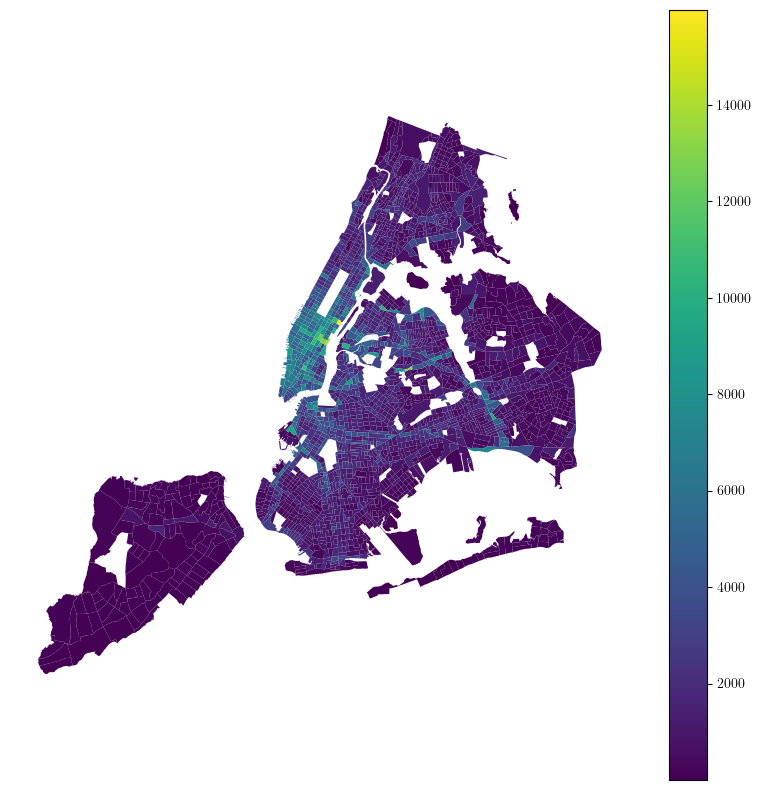

In [7]:

fig, ax = plt.subplots(figsize=(10,10)) 

ct_nyc.merge(analysis_df[['GEOID', 'image_density']], on='GEOID').plot(ax=ax, column='image_density', legend=True)


ax.set_axis_off()

In [8]:
analysis_df['area'].sum() / (5280**2)

np.float64(258.5841108351688)

In [9]:
analysis_df.columns

Index(['BoroName', 'BoroCT2020', 'NTAName', 'CDTANAME', 'PUMA',
       'empirical_estimate', 'p_y', 'p_y_CI_lower', 'p_y_CI_upper',
       'n_images_by_area', 'empirical_estimate_p_alop',
       'at_least_one_positive_image_by_area',
       'at_least_one_positive_image_by_area_CI_lower',
       'at_least_one_positive_image_by_area_CI_upper', 'total_population',
       'nhl_white_alone', 'nhl_black_alone', 'hispanic_alone',
       'nhl_asian_alone', 'n_children', 'n_elderly', 'total_households',
       'num_households_with_internet', 'num_households_with_smartphone',
       'median_household_income', 'num_high_school_graduates',
       'num_bachelors_degree', 'num_graduate_degree',
       'num_limited_english_speaking_households', 'ft_elevation_min',
       'ft_elevation_max', 'ft_elevation_mean', 'area', 'n_floodnet_sensors',
       'n_catch_basins', 'catch_basin_density', 'cb_days_clogged',
       'has_clogged_cb_complaint', 'cb_avg_resolution_time',
       'dep_moderate_1_area', 'dep

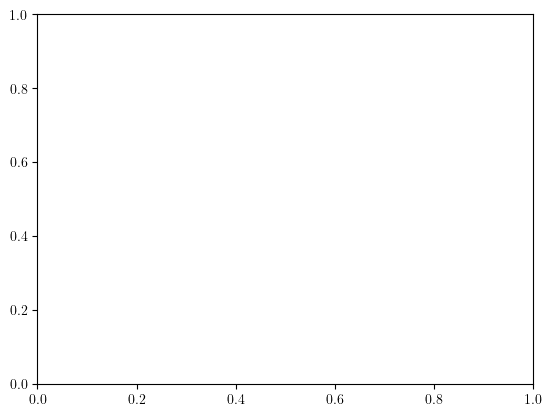

In [10]:
fig, ax = plt.subplots() 

(array([1.435e+03, 4.720e+02, 1.650e+02, 8.500e+01, 5.100e+01, 1.900e+01,
        1.100e+01, 1.000e+00, 3.000e+00, 1.000e+00]),
 array([5.92575710e-01, 1.59723085e+03, 3.19386913e+03, 4.79050741e+03,
        6.38714569e+03, 7.98378396e+03, 9.58042224e+03, 1.11770605e+04,
        1.27736988e+04, 1.43703371e+04, 1.59669753e+04]),
 <BarContainer object of 10 artists>)

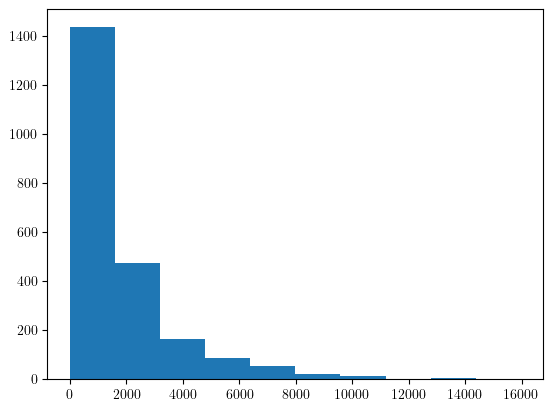

In [11]:
plt.hist(analysis_df['image_density'])

(array([  1.,   0.,   2.,  15.,  47., 165., 538., 900., 456., 119.]),
 array([-0.22725615,  0.21579173,  0.65883961,  1.10188749,  1.54493537,
         1.98798325,  2.43103113,  2.87407901,  3.31712689,  3.76017477,
         4.20322265]),
 <BarContainer object of 10 artists>)

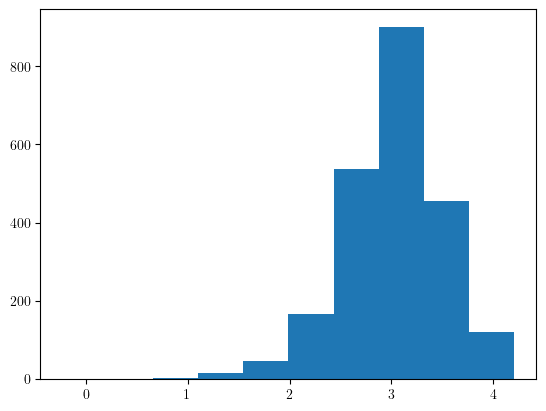

In [12]:
plt.hist(analysis_df['log_image_density'])

## 2. Descriptive Statistics

In [13]:
ses_cols = [
    'frac_white', 'frac_black', 'frac_hispanic', 'frac_asian',
    'frac_bachelors', 'frac_grad',
    'frac_children', 'frac_elderly',
    'frac_internet', 'frac_smartphone',
    'frac_limited_english',
    'median_household_income',
]

density_cols = ['n_images_by_area', 'image_density', 'log_image_density']

analysis_df[density_cols + ses_cols].describe().round(4)

,n_images_by_area,image_density,log_image_density,frac_white,frac_black,frac_hispanic,frac_asian,frac_bachelors,frac_grad,frac_children,frac_elderly,frac_internet,frac_smartphone,frac_limited_english,median_household_income
count,2243.0000,2243.0000,2243.0000,2243.0000,2243.0000,2243.0000,2243.0000,2243.0000,2243.0000,2243.0000,2243.0000,2232.0000,2232.0000,2232.0000,2192.0000
mean,370.0103,1746.1047,3.0191,0.3087,0.2194,0.2696,0.1508,0.1660,0.1193,0.2020,0.1633,0.8902,0.8923,0.1426,88549.2418
std,456.2468,1867.4704,0.4847,0.2782,0.2633,0.2197,0.1736,0.0938,0.1003,0.0799,0.0808,0.0889,0.0834,0.1330,42443.0159
min,1.0000,0.5926,-0.2273,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,11612.0000
25%,117.0000,568.3815,2.7546,0.0419,0.0164,0.1014,0.0255,0.0983,0.0465,0.1526,0.1106,0.8554,0.8609,0.0402,60240.7500
50%,214.0000,1153.3751,3.0620,0.2363,0.0819,0.1961,0.0826,0.1498,0.0927,0.1989,0.1547,0.9072,0.9077,0.1037,81981.5000
75%,427.0000,2117.9031,3.3259,0.5461,0.3744,0.3911,0.2152,0.2159,0.1558,0.2465,0.2045,0.9492,0.9439,0.2133,107326.7500
max,5279.0000,15966.9753,4.2032,1.0000,1.0000,1.0000,0.9124,1.0000,0.6923,0.6435,1.0000,1.0000,1.0000,1.0000,250001.0000


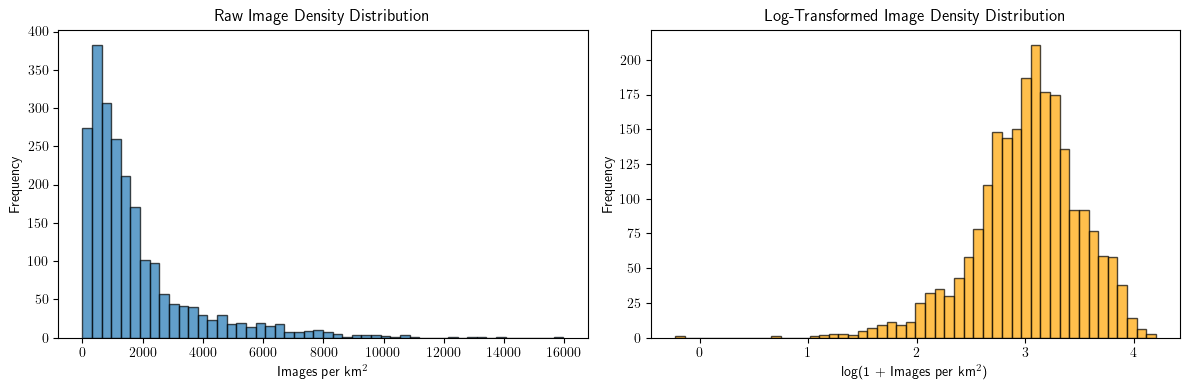

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(analysis_df['image_density'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(r'Images per km$^2$')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Raw Image Density Distribution')

axes[1].hist(analysis_df['log_image_density'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel(r'log(1 + Images per km$^2$)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Image Density Distribution')

plt.tight_layout()
plt.show()

## 3. Correlation Matrix

In [15]:
ses_labels = {
    'frac_white': 'Frac. White',
    'frac_black': 'Frac. Black',
    'frac_hispanic': 'Frac. Hispanic',
    'frac_asian': 'Frac. Asian',
    'frac_bachelors': "Frac. Bachelor's",
    'frac_grad': 'Frac. Graduate',
    'frac_children': 'Frac. Children',
    'frac_elderly': 'Frac. Elderly',
    'frac_internet': 'Frac. Internet',
    'frac_smartphone': 'Frac. Smartphone',
    'frac_limited_english': 'Frac. Limited English',
    'median_household_income': 'Median HH Income',
}

corr_cols = ['log_image_density'] + ses_cols
# Keep NAs here so both the per-variable loop (below) and the heatmap
# (pd.DataFrame.corr, next cell) do pairwise deletion per variable pair.
corr_df = analysis_df[corr_cols]

# Per-variable Pearson r, r^2 (variance explained), and p-value
r2_values = {}
pvalues = {}
directions = {}
for col in ses_cols:
    valid = corr_df[['log_image_density', col]].dropna()
    r, p = pearsonr(valid['log_image_density'], valid[col])
    label = ses_labels[col]
    r2_values[label] = r ** 2
    pvalues[label] = p
    directions[label] = '+' if r >= 0 else '-'

r2_series = pd.Series(r2_values)
pval_series = pd.Series(pvalues)
dir_series = pd.Series(directions)


def sig_stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''


corr_summary = pd.DataFrame({
    'Pearson r^2': r2_series.round(4),
    'Direction': dir_series,
    'p-value': pval_series,
    'Sig.': pval_series.map(sig_stars),
})
corr_summary


,Pearson r^2,Direction,p-value,Sig.
Frac. White,0.0011,+,1.135041e-01,
Frac. Black,0.0107,-,9.227057e-07,***
Frac. Hispanic,0.0025,+,1.860222e-02,*
Frac. Asian,0.0003,+,4.368811e-01,
Frac. Bachelor's,0.1052,+,4.080231e-56,***
Frac. Graduate,0.0830,+,3.963914e-44,***
Frac. Children,0.0279,-,1.750878e-15,***
Frac. Elderly,0.0282,-,1.223374e-15,***
Frac. Internet,0.0018,+,4.265134e-02,*
Frac. Smartphone,0.0132,+,5.138366e-08,***


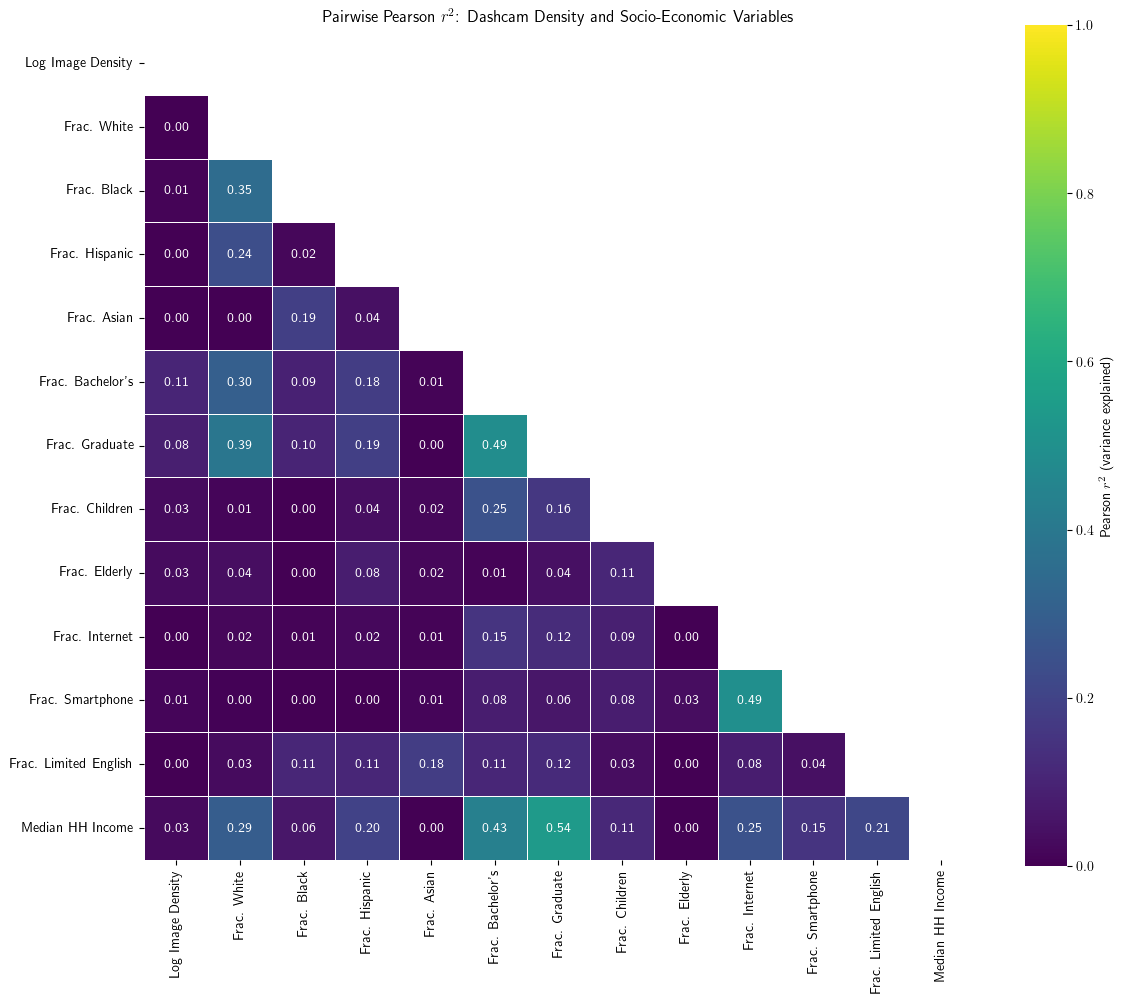

In [16]:
# Full heatmap of Pearson r^2 (variance explained) among all variables
heatmap_df = corr_df.rename(columns={'log_image_density': 'Log Image Density', **ses_labels})
corr_full = heatmap_df.corr()
r2_full = corr_full ** 2

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(r2_full, dtype=bool))
sns.heatmap(r2_full, mask=mask, annot=True, fmt='.2f', cmap='viridis',
            vmin=0, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': r'Pearson $r^2$ (variance explained)'})
ax.set_title(r'Pairwise Pearson $r^2$: Dashcam Density and Socio-Economic Variables')
plt.tight_layout()
plt.show()


## 4. Bivariate Scatter Plots

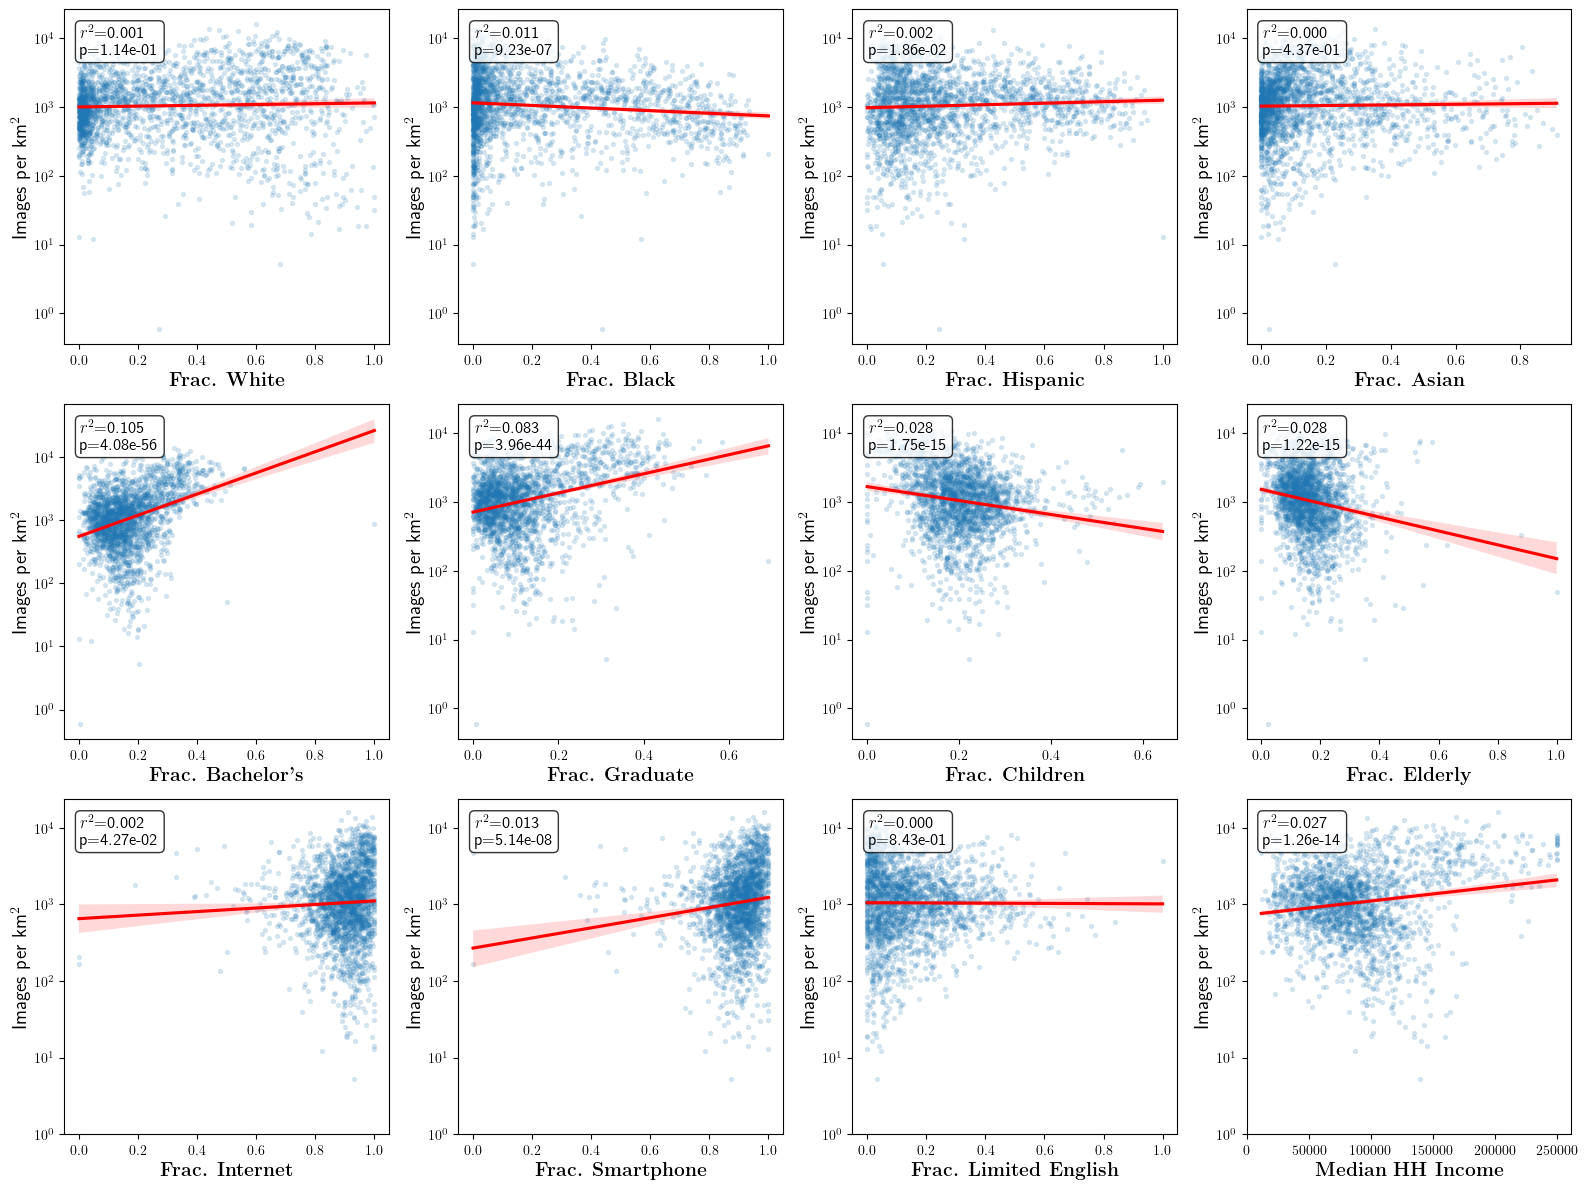

In [17]:
n_vars = len(ses_cols)
ncols = 4
nrows = (n_vars + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(ses_cols):
    ax = axes[i]
    valid = analysis_df[['log_image_density', col]].dropna()
    sns.regplot(x=col, y='log_image_density', data=valid, ax=ax,
                scatter_kws={'alpha': 0.15, 's': 8}, line_kws={'color': 'red'})
    r, p = pearsonr(valid[col], valid['log_image_density'])
    r2 = r ** 2
    ax.set_xlabel(rf"\bf {ses_labels[col]}", fontsize=14)
    ax.set_ylabel(r'Images per km$^2$', fontsize=14)
    ax.annotate(f'$r^2$={r2:.3f}\np={p:.2e}', xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=12, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    ax.set_yticks([0, 1, 2, 3, 4])
    ax.set_yticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)



plt.tight_layout()

plt.savefig(f"{c.PAPER_PATH}/figures/coverage_v_ses_scatters.png", dpi=300, pad_inches=0)


## 5. OLS Regression

In [18]:
ols_vars = [
    'frac_white', 'frac_black', 'frac_hispanic',
    'median_household_income',
    'frac_bachelors', 'frac_internet',
    'frac_limited_english', 'frac_elderly',
]

ols_df = analysis_df[['log_image_density'] + ols_vars].dropna()

X = sm.add_constant(ols_df[ols_vars])
y = ols_df['log_image_density']

model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_image_density   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     96.68
Date:                Sun, 31 May 2026   Prob (F-statistic):          6.75e-138
Time:                        12:31:28   Log-Likelihood:                -1205.5
No. Observations:                2192   AIC:                             2429.
Df Residuals:                    2183   BIC:                             2480.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

## 7. Export Tables for Paper

In [19]:
PAPER_PATH = Path(c.PAPER_PATH)
tables_dir = PAPER_PATH / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

# Correlation table: Pearson r^2 (variance explained) with direction, p-value, significance stars
corr_export = corr_summary[['Pearson r^2', 'Direction', 'p-value', 'Sig.']].copy()
corr_export['Pearson r^2'] = corr_export['Pearson r^2'].map(lambda x: f'{x:.3f}')
corr_export['p-value'] = corr_export['p-value'].map(lambda x: f'{x:.2e}')

with open(tables_dir / "coverage_ses_correlations.tex", "w") as f:
    f.write(corr_export.to_latex(
        caption=(
            "Pearson $r^2$ (variance explained) between log dashcam image density "
            "and socio-economic variables at the Census Tract level. The Direction "
            "column gives the sign of the underlying Pearson $r$. "
            r"$^{*}\,p < 0.05$, $^{**}\,p < 0.01$, $^{***}\,p < 0.001$."
        ),
        label="tab:coverage_ses_corr",
        column_format="lrcrc",
    ))
log.info(f"Correlation table saved to {tables_dir / 'coverage_ses_correlations.tex'}")

# OLS regression table
with open(tables_dir / "coverage_ses_ols.tex", "w") as f:
    f.write(model.summary().as_latex())
log.info(f"OLS table saved to {tables_dir / 'coverage_ses_ols.tex'}")


2026-05-31 12:31:28 - coverage-ses-corr - INFO - Correlation table saved to /share/ju/matt/bayflood/papers/natcities_bayflood_2025/tables/coverage_ses_correlations.tex


2026-05-31 12:31:28 - coverage-ses-corr - INFO - OLS table saved to /share/ju/matt/bayflood/papers/natcities_bayflood_2025/tables/coverage_ses_ols.tex
